![Pangchain chunking_260627_121633_1.jpg](<attachment:Pangchain chunking_260627_121633_1.jpg>)
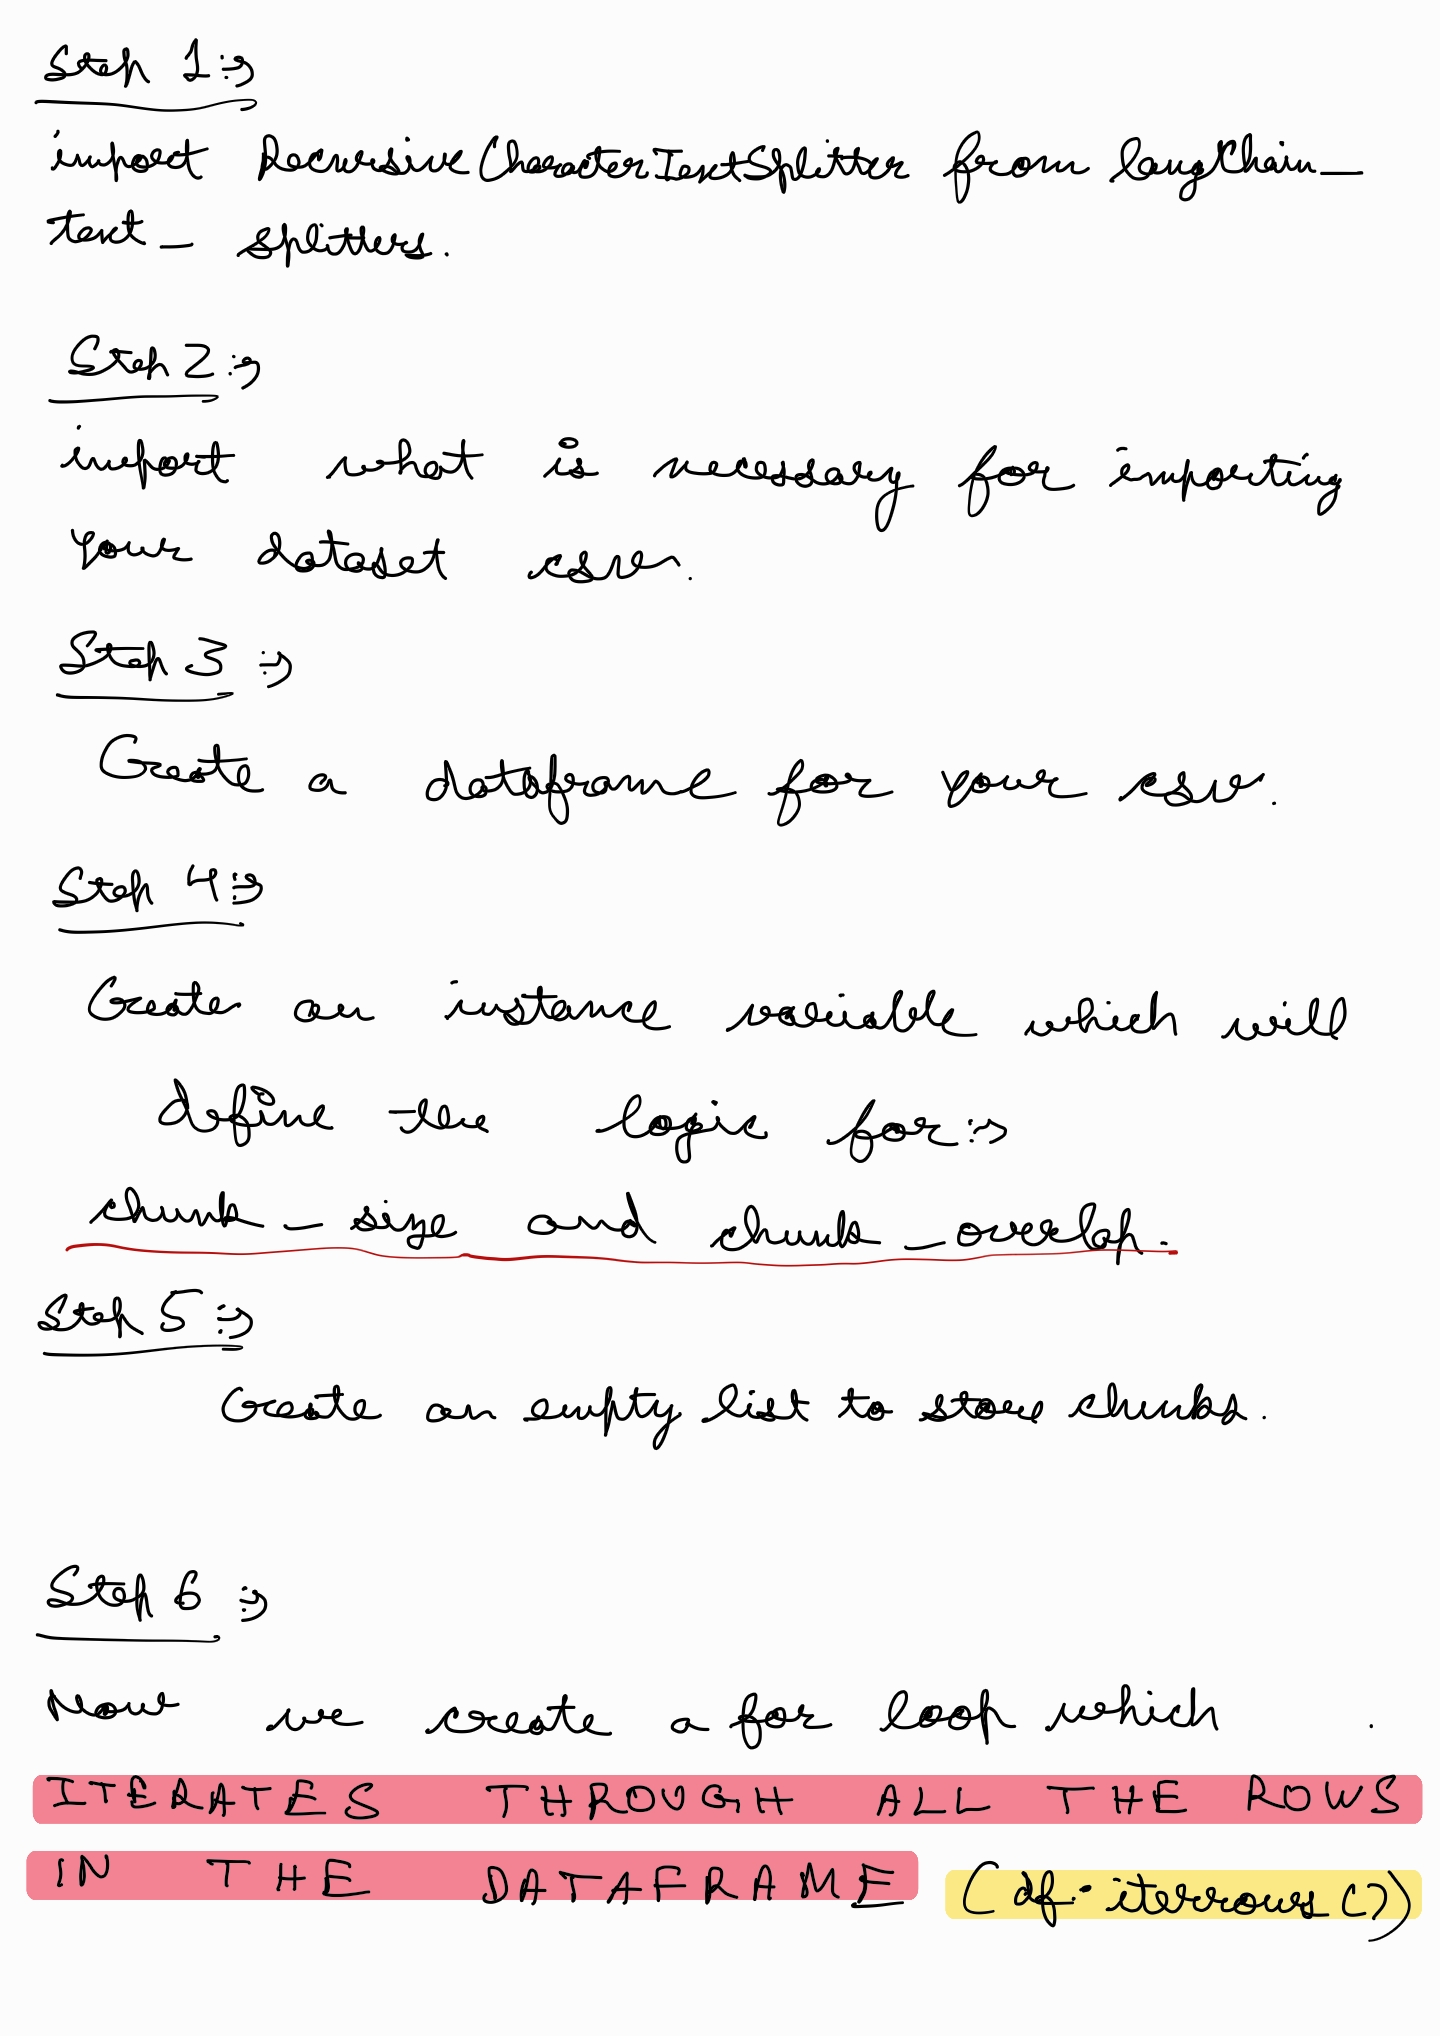

![Pangchain chunking_260627_121633_2.jpg](<attachment:Pangchain chunking_260627_121633_2.jpg>)
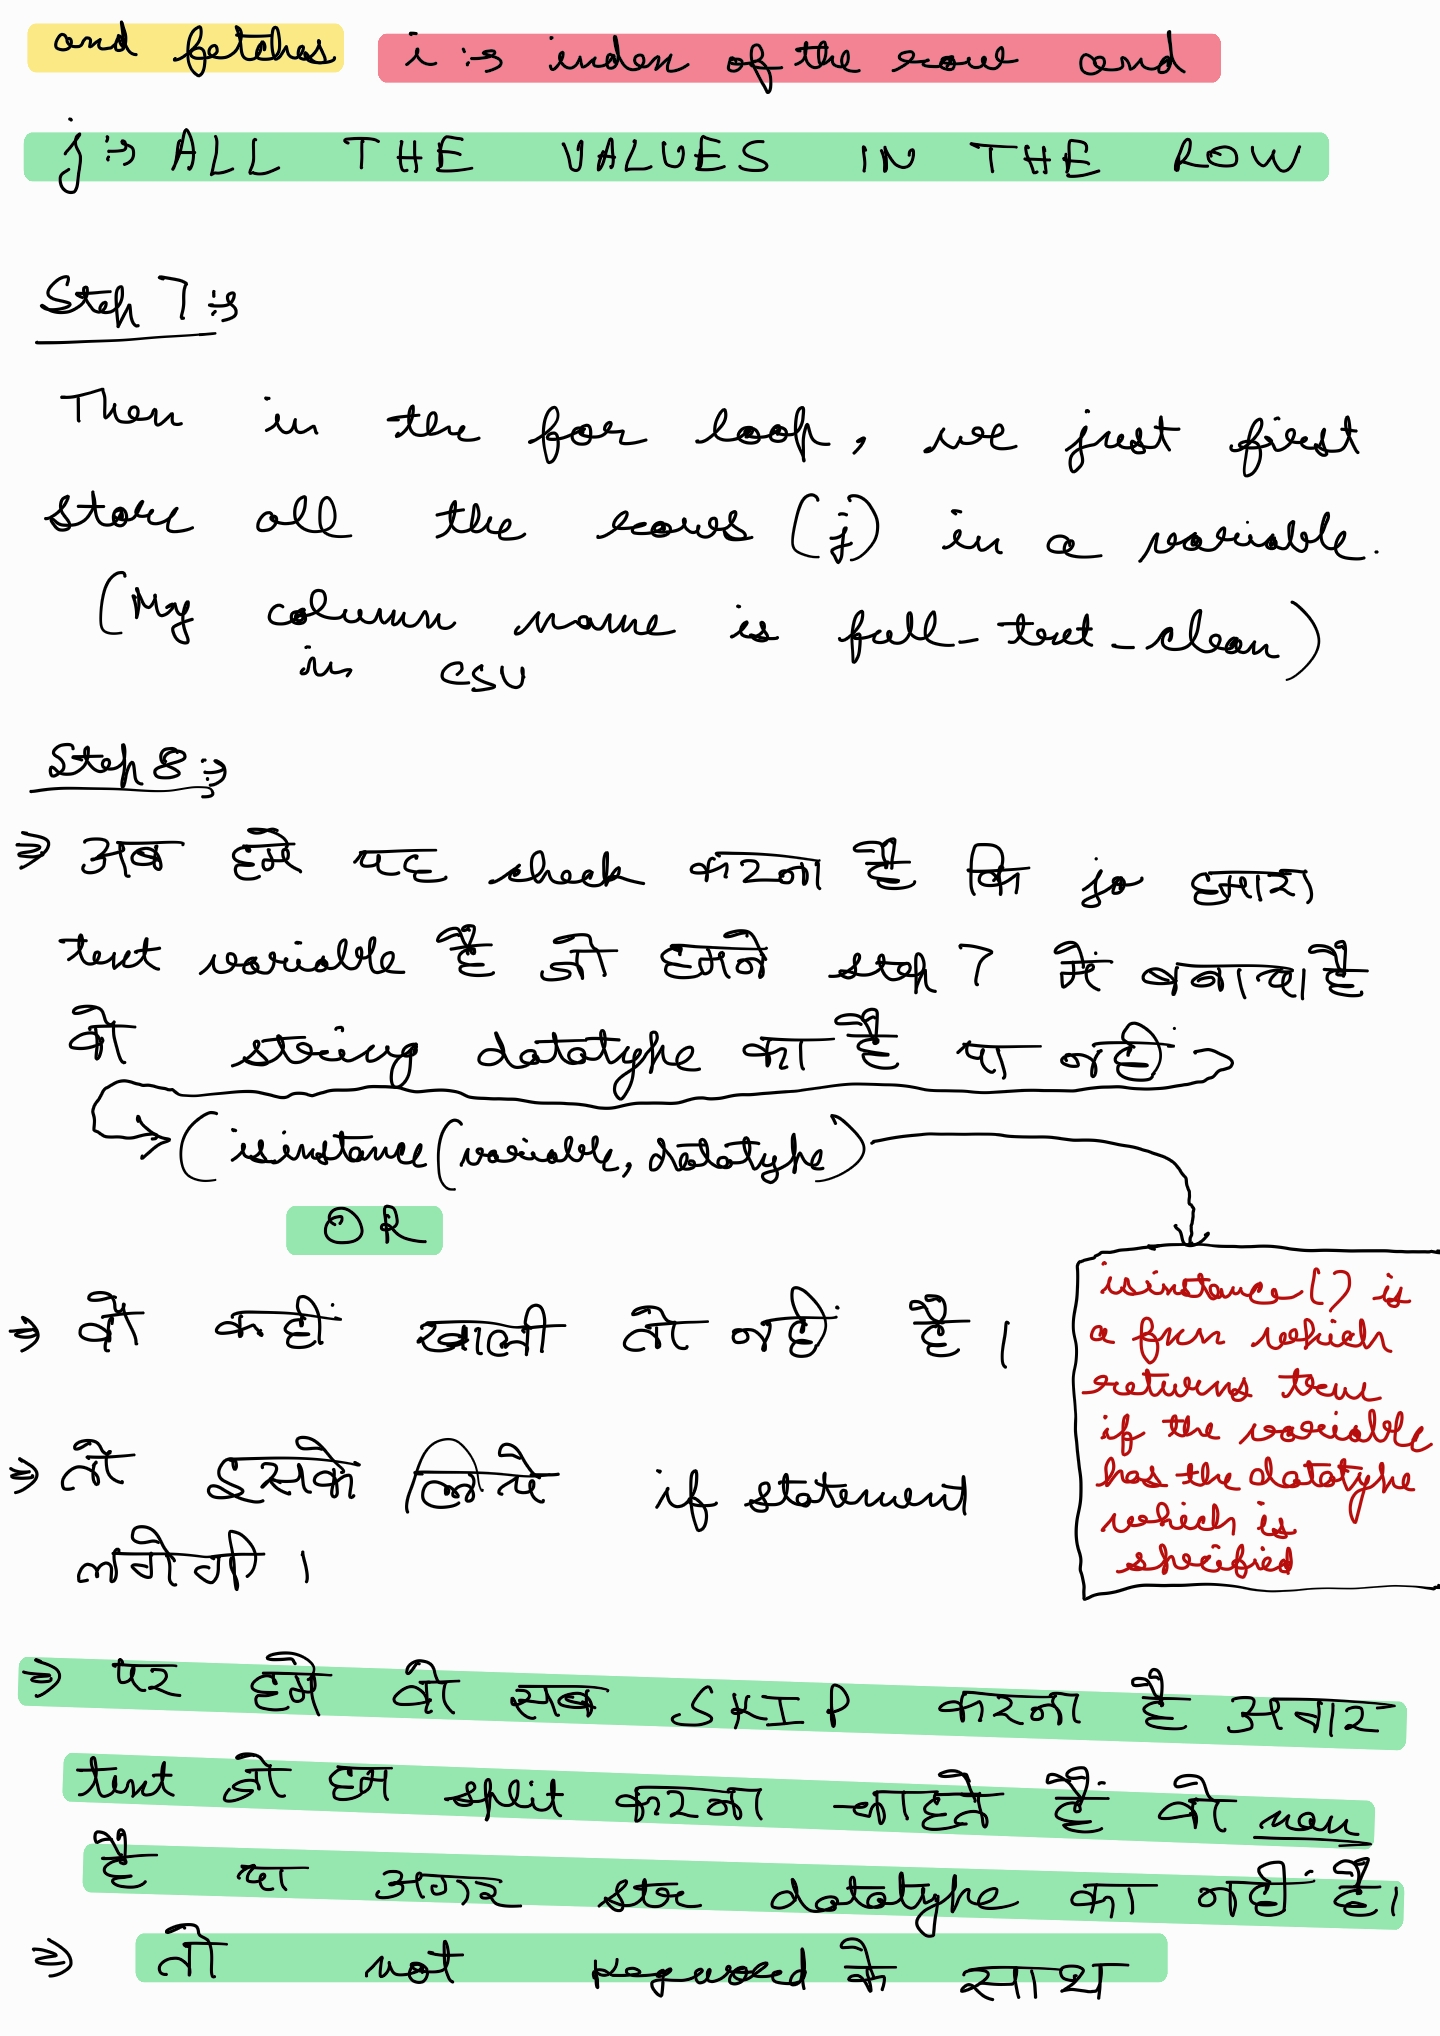

![Pangchain chunking_260627_121633_3.jpg](<attachment:Pangchain chunking_260627_121633_3.jpg>)
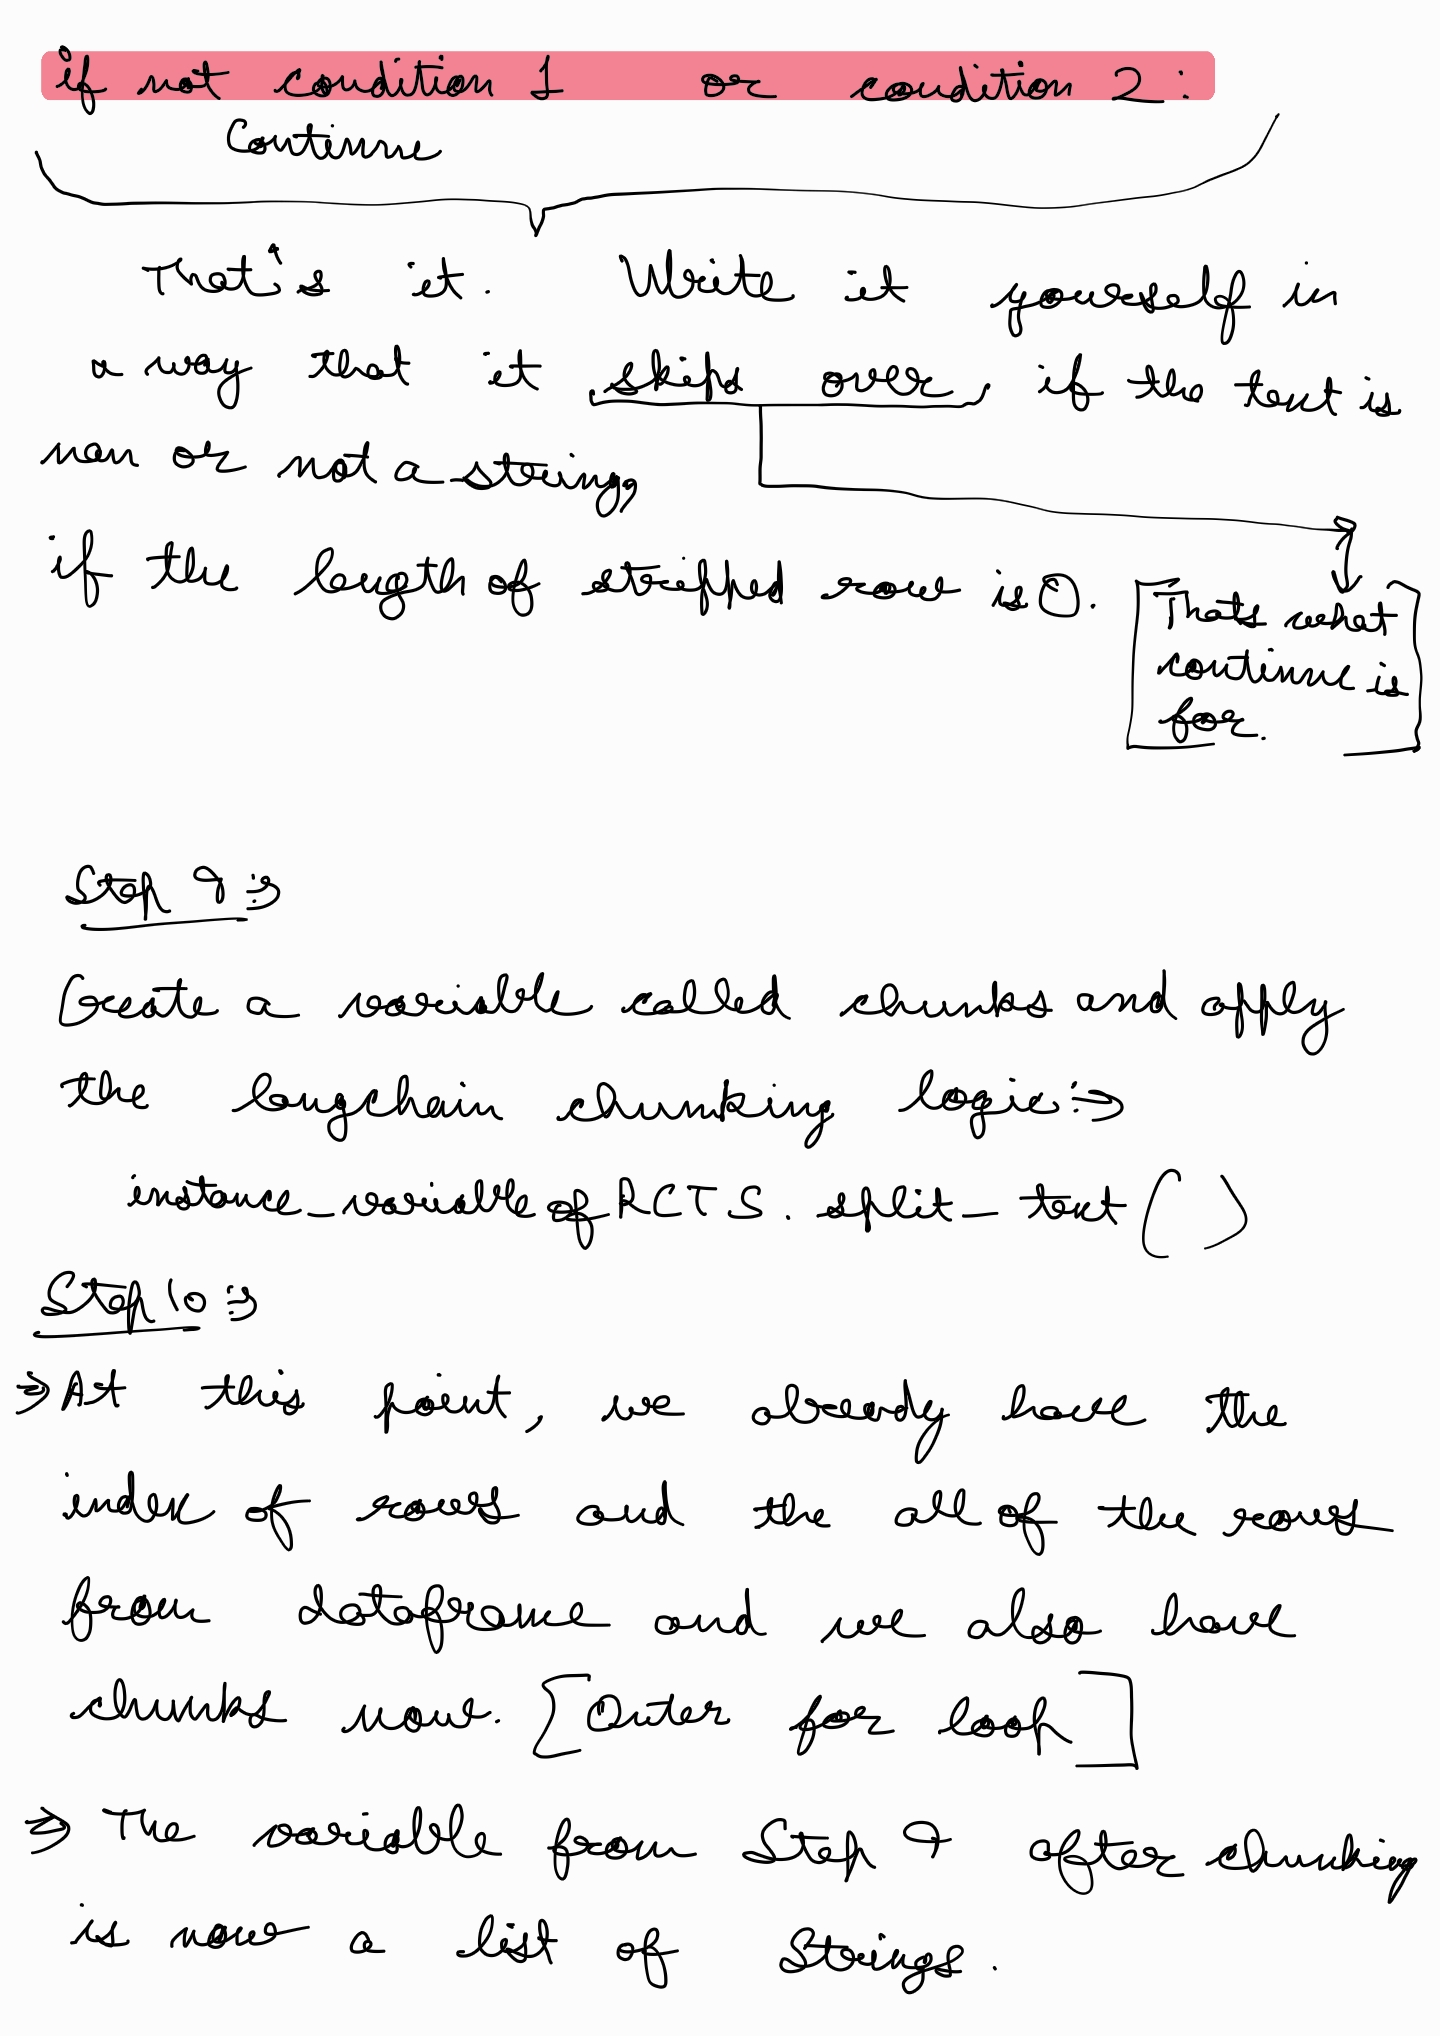

![Pangchain chunking_260627_121633_4.jpg](<attachment:Pangchain chunking_260627_121633_4.jpg>)
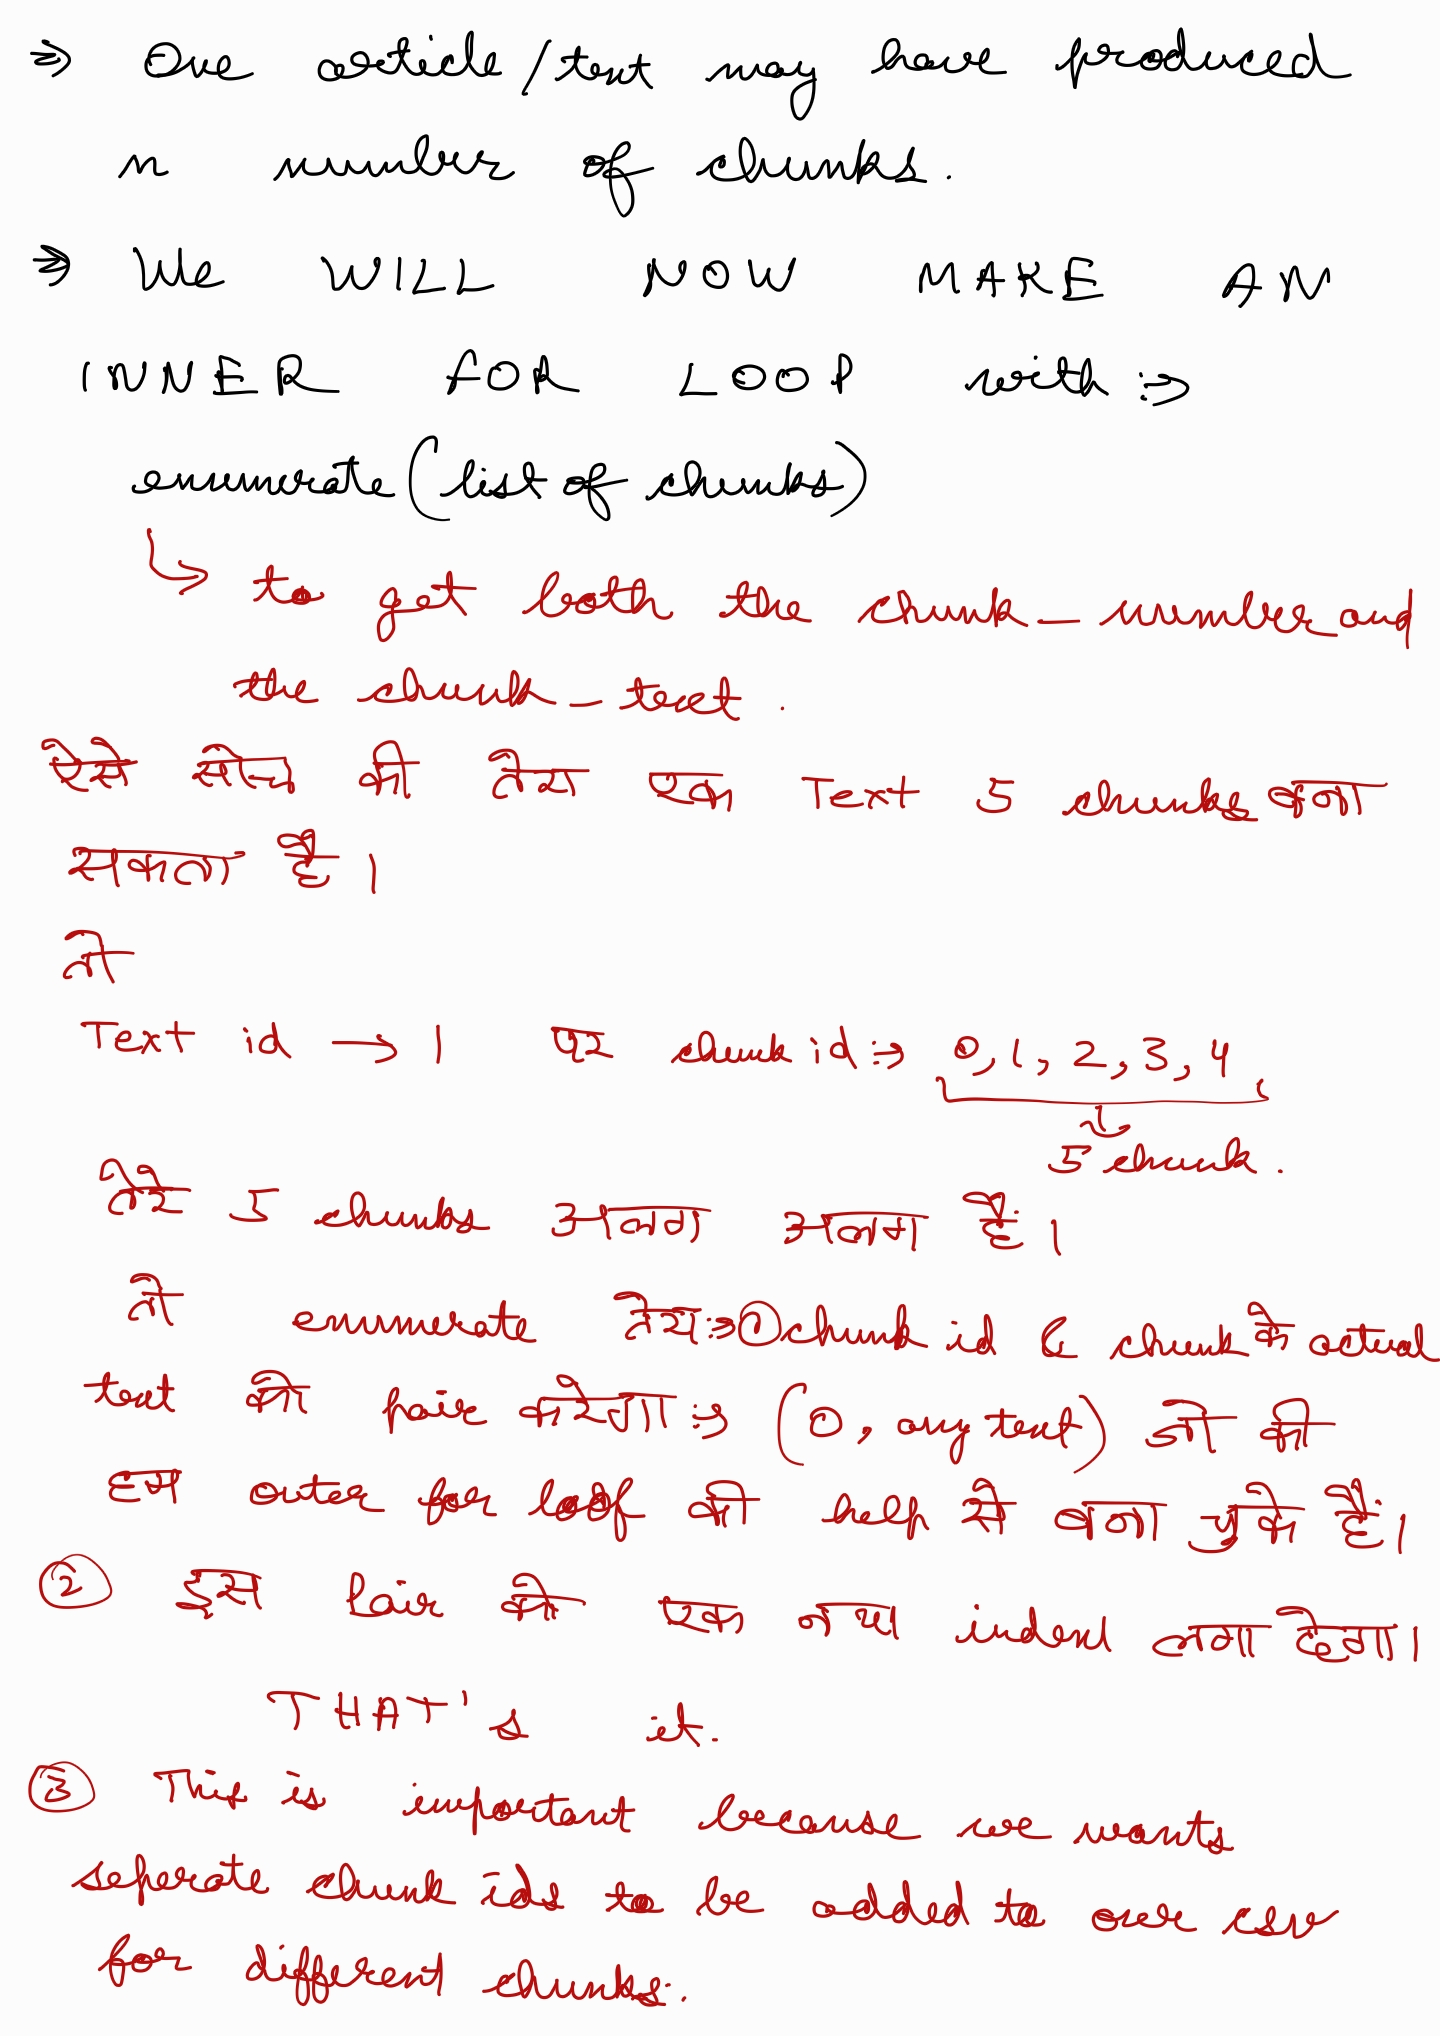

![Pangchain chunking_260627_121633_5.jpg](<attachment:Pangchain chunking_260627_121633_5.jpg>)
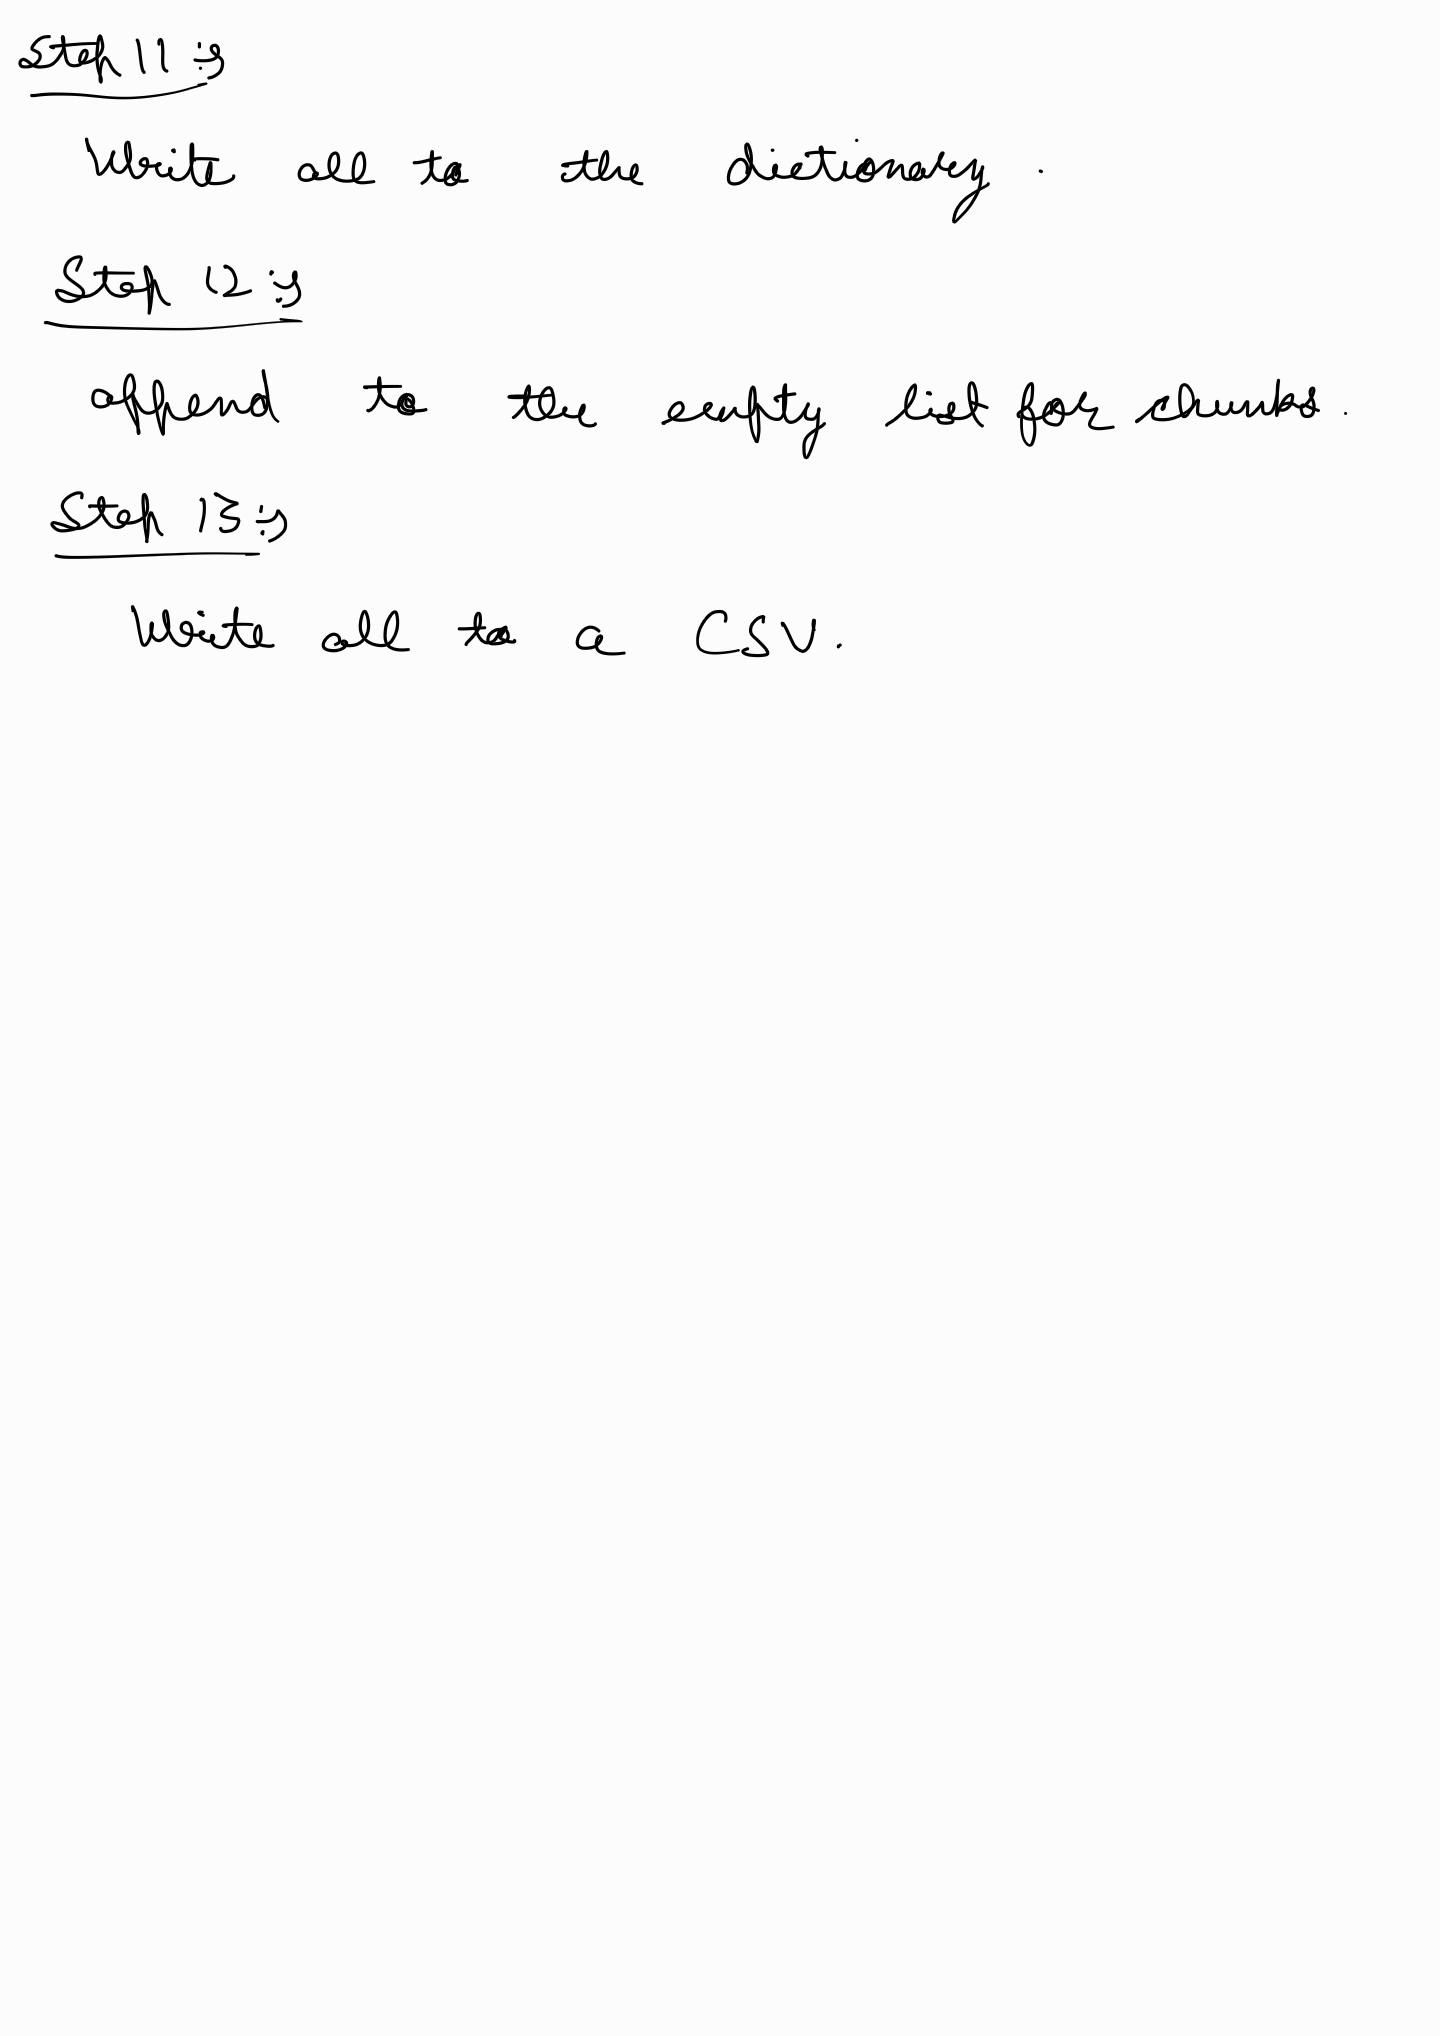

In [22]:
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
df=pd.read_csv("../../data/processed/nvidia_articles_cleaned.csv")

- The dictionary we will be writing to the csv in the end:-

chunk_row = {
            "doc_id":           doc_id,
            "chunk_id":         f"doc_{doc_id}_chunk_{chunk_num}",
            "source":           row["source"],
            "title":            row["title"],
            "url":              row["url"],
            "published":        row["published"],
            "matched_keywords": row["matched_keywords"],
            "relevance_score":  row["relevance_score"],
            "chunk_text":       chunk_text,
            "char_count":       len(chunk_text)
        }

In [23]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=250)

In [24]:
chonks=[]

In [25]:
for i, j in df.iterrows():
    texts=j["full_text_clean"]
    if not isinstance(texts, str) or len(texts.strip())==0:
        continue
    full_chunks=splitter.split_text(texts)
    for chunk_id, chunk_text in enumerate(full_chunks):
        chunk_row = {
            "doc_id":           i,
            "chunk_id":         f"doc_{i}_chunk_{chunk_id}",
            "source":           j["source"],
            "title":            j["title"],
            "url":              j["url"],
            "published":        j["published"],
            "matched_keywords": j["matched_keywords"],
            "relevance_score":  j["relevance_score"],
            "chunk_text":       chunk_text,
            "char_count":       len(chunk_text)
        }
        chonks.append(chunk_row)

In [26]:
df_chunks = pd.DataFrame(chonks)
df_chunks.to_csv("../../data/chunked/langChainchunks.csv", index=False)# Always add index = False or don't.... you'll see